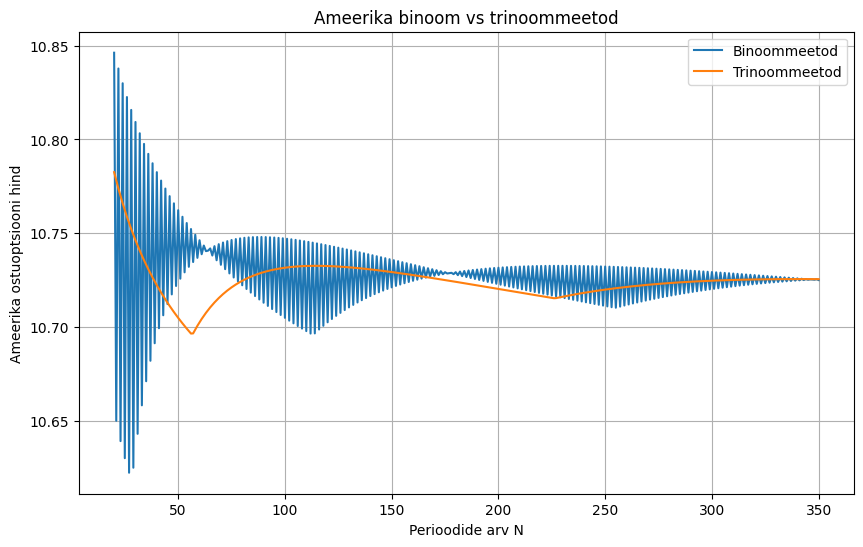

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

T = 1.3
S0 = 110
r = 0.03
sigma = np.sqrt(0.05)
X = 115.4

# Ameerika ostuoptsioon (call) binoommeetod
def American_callprice(S0, X, T, N, r, sigma):
    dt=T/N
    U=np.exp(sigma*np.sqrt(dt))
    D=np.exp(-sigma*np.sqrt(dt))
    R=(np.exp(r*dt))
    q=(R-D)/(U-D)
    V_old=np.zeros(N+1)
    V_new=np.zeros(N+1)
    for j in range(0,N+1):
        V_old[j]=max(S0*U**j*D**(N-j)-X,0)
    for m in range(N-1,-1,-1):
        for j in range(0,m+1):
            W=(q*V_old[j+1]+(1-q)*V_old[j])/R
            P=max(S0 * U**j * D**(m - j) - X, 0) 
            V_new[j] = np.maximum(P, W)
            V_old[j]=V_new[j]
    return(V_new[0])     

# Ameerika ostuoptsioon (call) trinoommeetod

def American_trinomial_call(S0, X, T, N, r, sigma):
    dt = T/N
    U = np.exp(sigma * np.sqrt(2 * dt))
    D = 1/U
    R = np.exp(r * dt)

    qu = ((np.exp(r * dt / 2) - np.sqrt(D)) / (np.sqrt(U) - np.sqrt(D)))**2
    qd = ((np.sqrt(U) - np.exp(r * dt / 2)) / (np.sqrt(U) - np.sqrt(D)))**2
    qm = 1 - qu - qd

    suurus = 2 * N + 1
    offset = N
    V_old = np.zeros(suurus)
    V_new = np.zeros(suurus)

    for j in range(-N, N + 1):
        V_old[j + offset] = max(S0 * U**j - X, 0)

    for m in range(N - 1, -1, -1):
        for j in range(-m, m + 1):
            i = j + offset
            jatkuvaartus = (qu * V_old[i + 1] + qm * V_old[i] + qd * V_old[i - 1]) / R
            exercise = max(S0 * U**j - X, 0)
            V_new[i] = np.maximum(jatkuvaartus, exercise)
        V_old[:] = V_new[:]

    return V_old[offset]
# Graafik 2: Ameerika ostuoptsiooni hinna konvergents binoom- ja trinoommeetodil

N_vals = range(20, 351)
V_bin = []
V_tri = []

for N in N_vals:
    V_bin.append(American_callprice(S0, X, T, N, r, sigma))
    V_tri.append(American_trinomial_call(S0, X, T, N, r, sigma))

plt.figure(figsize=(10, 6))
plt.plot(N_vals, V_bin, label="Binoommeetod")
plt.plot(N_vals, V_tri, label="Trinoommeetod")
plt.xlabel("Perioodide arv N")
plt.ylabel("Ameerika ostuoptsiooni hind")
plt.title("Ameerika binoom vs trinoommeetod")
plt.legend()
plt.grid(True)
plt.show()